# Paper results

**Data-driven reconstruction of effective drift--jump dynamics in an open trapped-ion system**

This notebook is intentionally compact. Scientific functions live under `src/trapped_ion_pdmp/`; the cells below only load and display the frozen manuscript outputs.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path("..")
RESULTS = ROOT / "results"


## 1. Model and workflow

,Parameter,Symbol,Value
0,Number of ions,N,2
1,Phonon cutoff,N_m,4
2,Lamb-Dicke parameter,eta,0.15
3,Rabi frequency,Omega,1.0
4,COM weight,u_i,1/sqrt(2)
5,Spin-phonon coupling,g,0.053033
6,Relaxation time,T_1,80.0
7,Pure dephasing,T_phi,infinity
8,Phonon damping,kappa,0.0
9,Initial state,NaN,"|10,0_ph>"


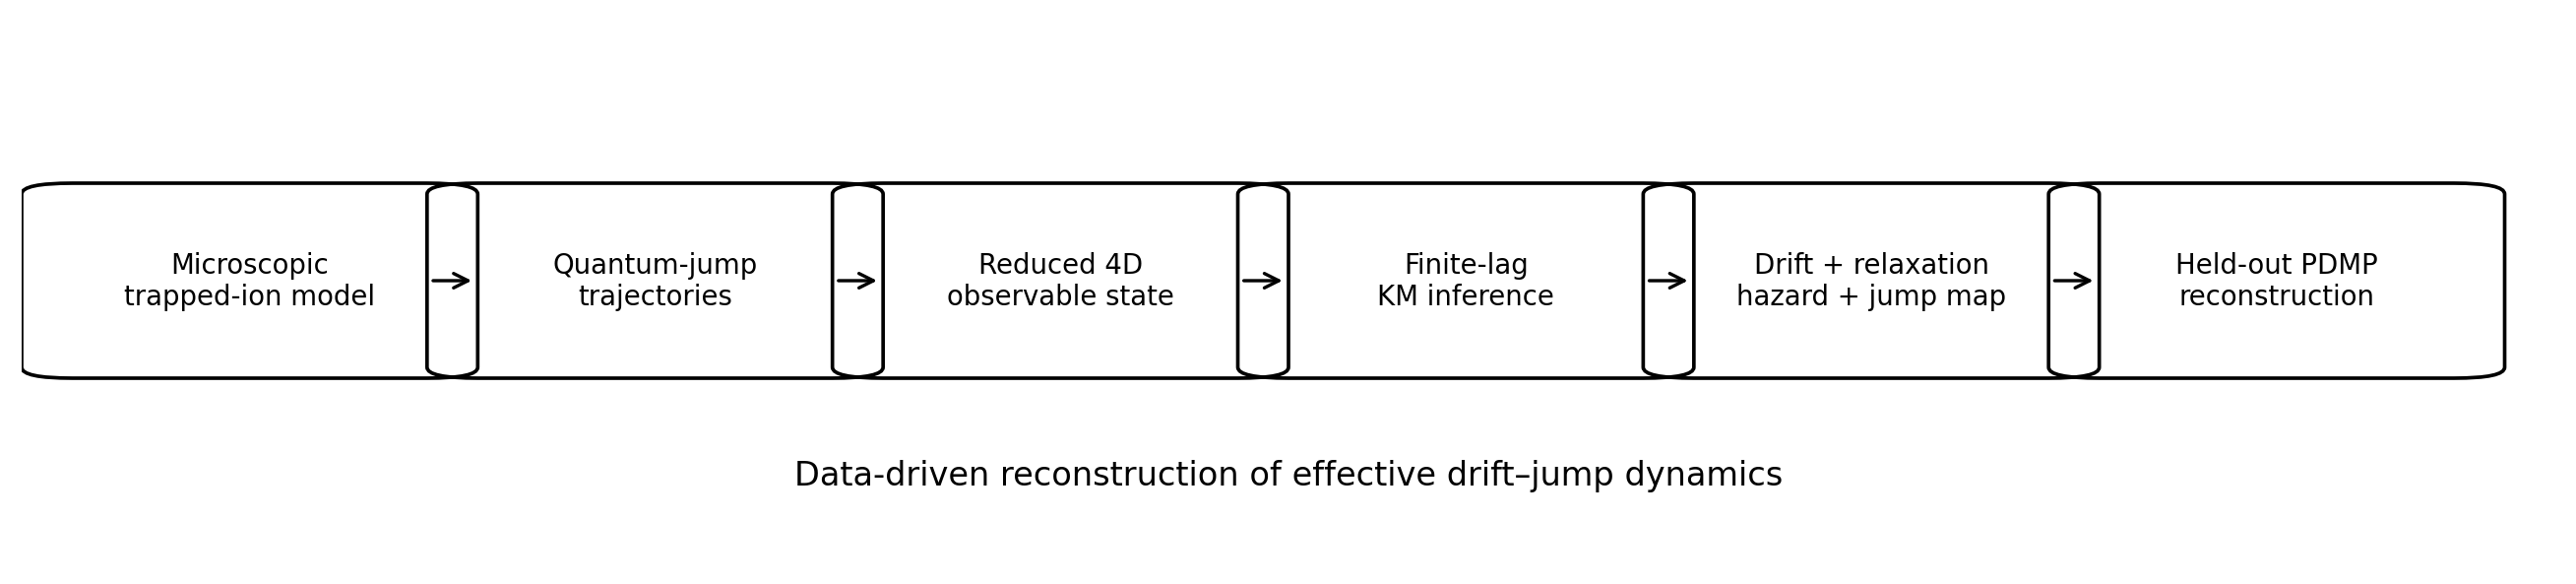

In [2]:
display(pd.read_csv(RESULTS / "tables" / "Table_1_Model_Parameters.csv"))
display(Image(filename=RESULTS / "figures" / "Figure_1_Method_Workflow.png"))


## 2. Finite-lag stochastic structure

,lag_steps,tau,n_cont_train,n_jump_windows,drift_NRMSE,median_D2_trace,median_D2_trace_over_tau,worst_D2_eigenvalue,PSD_violation_fraction
0,1,0.092153,92125,125,0.000931,0.000377,0.004089,-6.950842e-19,0.0
1,2,0.184307,91985,250,0.000764,0.000743,0.004032,-1.154571e-18,0.0
2,4,0.368614,91705,500,0.001605,0.001477,0.004007,-1.210426e-18,0.0
3,8,0.737227,91145,1000,0.000817,0.003028,0.004107,-3.411416e-18,0.0


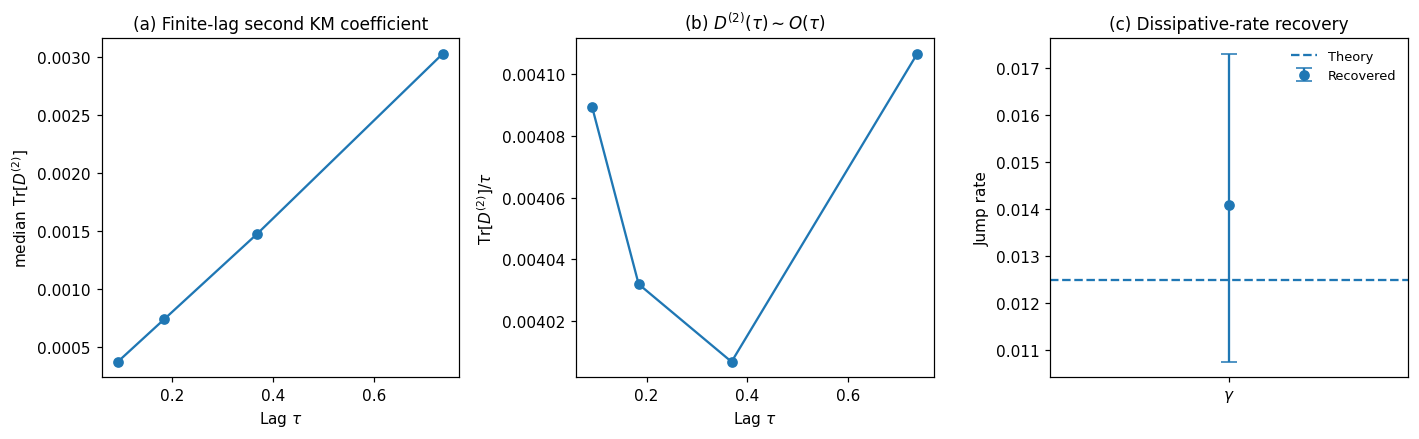

In [3]:
display(pd.read_csv(RESULTS / "supplementary" / "d2_finite_lag_scaling.csv"))
display(Image(filename=RESULTS / "figures" / "Figure_2_Stochastic_Structure.png"))


## 3. Physical-rate recovery

,Parameter,Theory,Estimate,Relative_error,Bootstrap_CI95_low,Bootstrap_CI95_high,Theory_in_CI
0,g,0.053033,0.053021,0.000217,0.053017,0.053044,True
1,gamma,0.012500,0.014098,0.127800,0.010753,0.017317,True


,Relation,Estimated_slope,Theoretical_slope,Relative_error,R2
0,g vs eta,0.353485,0.353553,0.000193,1.000000
1,g vs Omega,0.053021,0.053033,0.000219,0.999999
2,gamma vs 1/T1,1.095008,1.000000,0.095000,0.967142


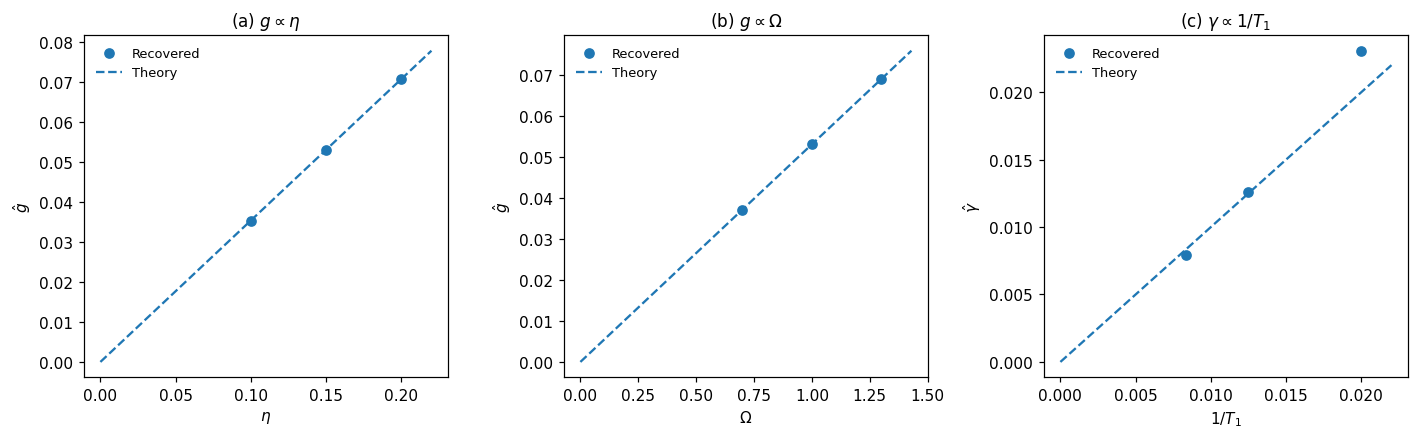

In [4]:
display(pd.read_csv(RESULTS / "tables" / "Table_2_Physical_Parameter_Recovery.csv"))
display(pd.read_csv(RESULTS / "tables" / "Table_3_Parametric_Scaling.csv"))
display(Image(filename=RESULTS / "figures" / "Figure_3_Physical_Rate_Recovery.png"))


## 4. Independent PDMP reconstruction

,mean_NRMSE,variance_NRMSE,wasserstein,survival_RMSE,jump_fraction_error,mean_covariance_error,physical_violation_fraction,max_population_violation
0,0.047447,0.054333,0.034444,0.080019,0.073333,0.128736,0.0,0.0


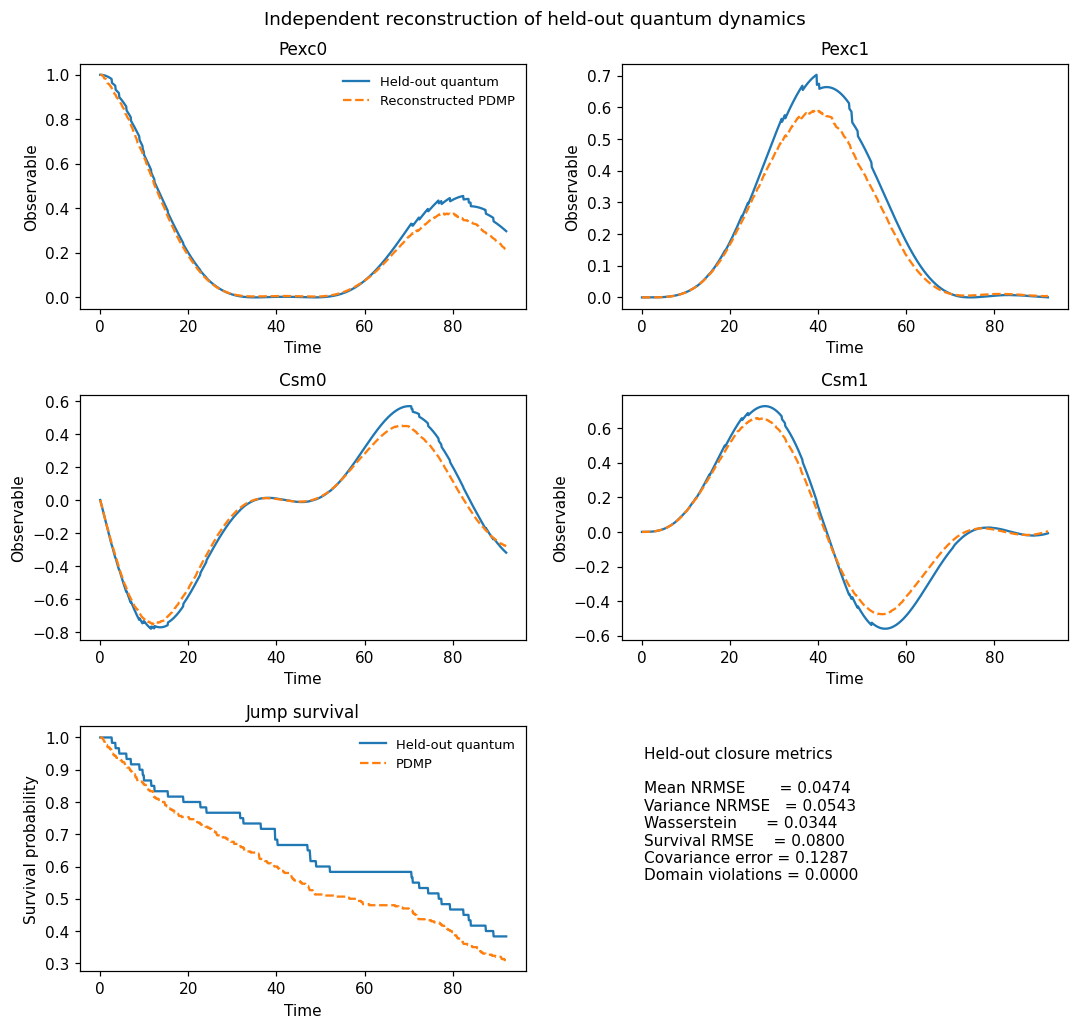

In [5]:
frozen = json.loads((RESULTS / "frozen_metrics.json").read_text())
display(pd.DataFrame([frozen["final_pdmp_300"]]))
display(Image(filename=RESULTS / "figures" / "Figure_5_Independent_PDMP_Reconstruction.png"))


## 5. Model ablation

,model,mean_NRMSE,variance_NRMSE,wasserstein,survival_RMSE,covariance_error,physical_violation_fraction
0,Drift-only,0.183742,0.405829,0.126699,0.369912,1.000000,0.000000
1,Gaussian diffusion,0.196909,0.652859,0.228445,0.369912,1.714459,0.400067
2,PDMP,0.055093,0.053569,0.038281,0.096942,0.124873,0.000000


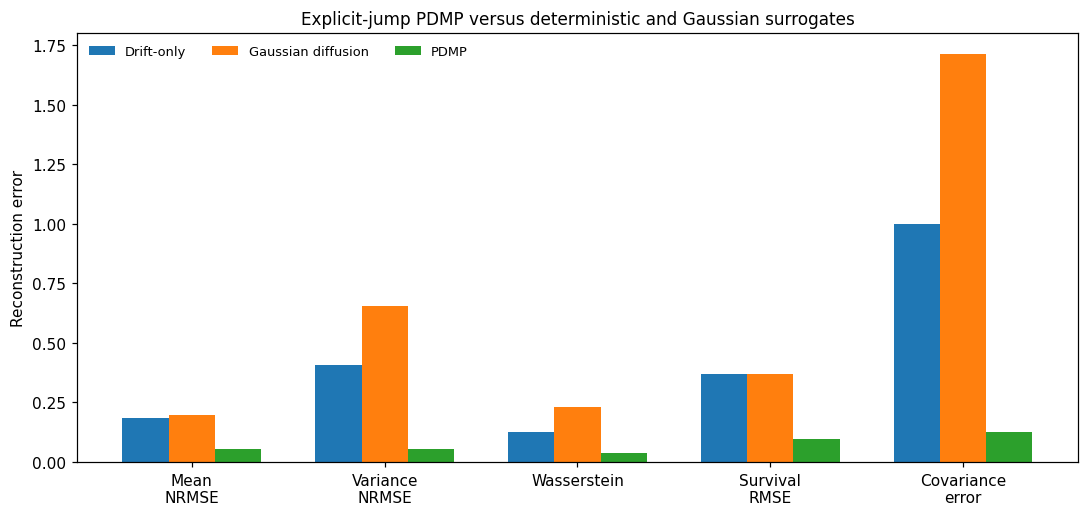

In [6]:
display(pd.read_csv(RESULTS / "tables" / "Table_4_Model_Ablation.csv"))
display(Image(filename=RESULTS / "figures" / "Figure_4_Model_Ablation.png"))


## 6. Appendix-level validation

In [7]:
display(pd.read_csv(RESULTS / "supplementary" / "simulator_validation.csv"))
display(pd.read_csv(RESULTS / "supplementary" / "robustness_summary.csv"))
display(pd.read_csv(RESULTS / "supplementary" / "nojump_path_validation.csv"))


,Validation,Absolute_error
0,Carrier dynamics,5.856664e-08
1,Red-sideband dynamics,1.390274e-08
2,Blue-sideband dynamics,1.390274e-08
3,Two-ion excitation conservation,4.440892e-16
4,T1 relaxation,1.459577e-08
5,Pure dephasing,2.601783e-08
6,Dephasing population conservation,0.000000e+00
7,Phonon damping,1.914074e-08


,test,metric,value
0,Independent seeds — g,coefficient of variation,0.000190
1,Independent seeds — gamma,coefficient of variation,0.152854
2,Time-step convergence — g,maximum relative error,0.000276
3,Time-step robustness — gamma,maximum relative error,0.004559
4,Kernel-neighbor sensitivity,maximum relative drift change,0.013484
5,PSD-safe diffusion estimator,PSD violation fraction,0.000000


,variable,RMSE,NRMSE,max_abs_error,max_normalized_error,mean_bias,correlation
0,Pexc0,0.025673,0.025673,0.085982,0.085982,0.004006,0.997991
1,Pexc1,0.014268,0.014329,0.032907,0.033047,-0.002664,0.999410
2,Csm0,0.059124,0.031099,0.155787,0.081944,-0.018870,0.995059
3,Csm1,0.030115,0.015793,0.070919,0.037192,0.005048,0.998724


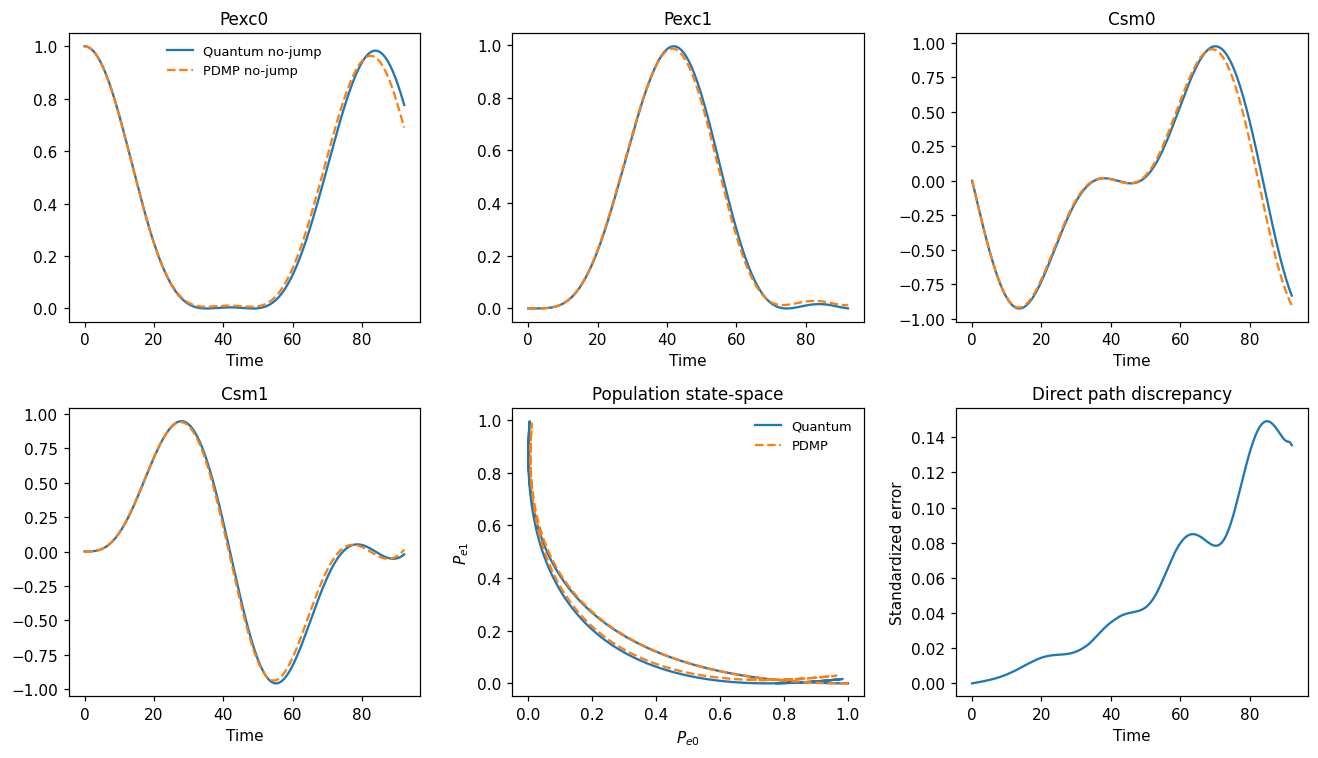

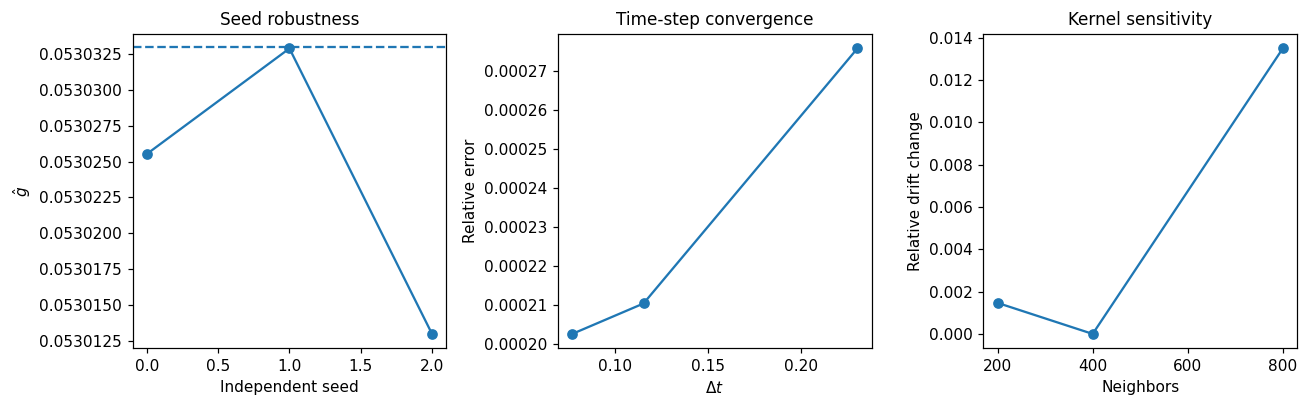

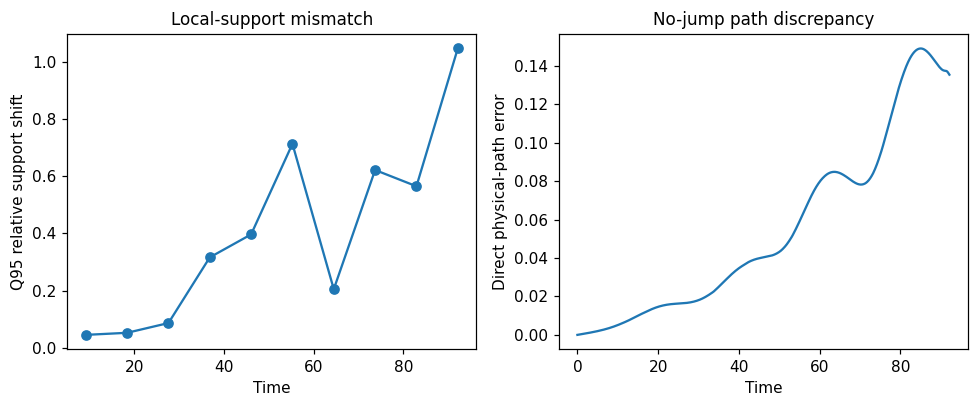

In [8]:
display(Image(filename=RESULTS / "figures" / "Figure_6_NoJump_Physical_Path.png"))
display(Image(filename=RESULTS / "supplementary" / "Figure_S1_Robustness.png"))
display(Image(filename=RESULTS / "supplementary" / "Figure_S2_Support_Limitation.png"))


### Reproduction note

The frozen outputs above are preserved for manuscript consistency. A fresh simulation writes to `results/generated/` and never overwrites these files. Run:

```bash
python scripts/reproduce_full.py
```

The event record is used to separate no-jump and jump-containing increments, and the relaxation hazard uses the physics-informed form \(\lambda_i=\gamma P_{e,i}\).
